In [42]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

import torch
import torch.nn as nn
import torch.nn.functional as F

In [43]:
columns = ['engine_id', 'cycle', 'setting1', 'setting2', 'setting3'] + \
          [f'sensor{i}' for i in range(1, 22)]

In [44]:
train_path = "project/data/train_FD001.txt"

train = pd.read_csv(
    train_path,
    sep=r"\s+",
    header=None
)

train.columns = columns
train.head()

,engine_id,cycle,setting1,setting2,setting3,sensor1,sensor2,sensor3,sensor4,sensor5,...,sensor12,sensor13,sensor14,sensor15,sensor16,sensor17,sensor18,sensor19,sensor20,sensor21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [45]:
engine_life = train.groupby('engine_id')['cycle'].max()

print(engine_life.head())
print(engine_life.describe())

engine_id
1    192
2    287
3    179
4    189
5    269
Name: cycle, dtype: int64
count    100.000000
mean     206.310000
std       46.342749
min      128.000000
25%      177.000000
50%      199.000000
75%      229.250000
max      362.000000
Name: cycle, dtype: float64


In [46]:
setting_cols = ['setting1', 'setting2', 'setting3']
sensor_cols = [f'sensor{i}' for i in range(1, 22)]

In [47]:
sensor_variance = train[sensor_cols].var().sort_values()
print(sensor_variance)

sensor19    0.000000e+00
sensor18    0.000000e+00
sensor16    2.422479e-28
sensor10    2.172333e-25
sensor5     1.152399e-23
sensor1     4.273435e-21
sensor6     1.929279e-06
sensor15    1.406628e-03
sensor8     5.038938e-03
sensor13    5.172330e-03
sensor21    1.171825e-02
sensor20    3.266927e-02
sensor11    7.133568e-02
sensor2     2.500533e-01
sensor12    5.439850e-01
sensor7     7.833883e-01
sensor17    2.398667e+00
sensor3     3.759099e+01
sensor4     8.101089e+01
sensor14    3.639005e+02
sensor9     4.876536e+02
dtype: float64


In [48]:
drop_sensors = ['sensor1', 'sensor5', 'sensor6', 'sensor10', 'sensor16', 'sensor18', 'sensor19']
selected_sensors = [s for s in sensor_cols if s not in drop_sensors]
data = train[['engine_id', 'cycle'] + selected_sensors].copy()
data.head()

,engine_id,cycle,sensor2,sensor3,sensor4,sensor7,sensor8,sensor9,sensor11,sensor12,sensor13,sensor14,sensor15,sensor17,sensor20,sensor21
0,1,1,641.82,1589.70,1400.60,554.36,2388.06,9046.19,47.47,521.66,2388.02,8138.62,8.4195,392,39.06,23.4190
1,1,2,642.15,1591.82,1403.14,553.75,2388.04,9044.07,47.49,522.28,2388.07,8131.49,8.4318,392,39.00,23.4236
2,1,3,642.35,1587.99,1404.20,554.26,2388.08,9052.94,47.27,522.42,2388.03,8133.23,8.4178,390,38.95,23.3442
3,1,4,642.35,1582.79,1401.87,554.45,2388.11,9049.48,47.13,522.86,2388.08,8133.83,8.3682,392,38.88,23.3739
4,1,5,642.37,1582.85,1406.22,554.00,2388.06,9055.15,47.28,522.19,2388.04,8133.80,8.4294,393,38.90,23.4044


In [49]:
scaler = MinMaxScaler()

data[selected_sensors] = scaler.fit_transform(data[selected_sensors])

data.head()

,engine_id,cycle,sensor2,sensor3,sensor4,sensor7,sensor8,sensor9,sensor11,sensor12,sensor13,sensor14,sensor15,sensor17,sensor20,sensor21
0,1,1,0.183735,0.406802,0.309757,0.726248,0.242424,0.109755,0.369048,0.633262,0.205882,0.199608,0.363986,0.333333,0.713178,0.724662
1,1,2,0.283133,0.453019,0.352633,0.628019,0.212121,0.100242,0.380952,0.765458,0.279412,0.162813,0.411312,0.333333,0.666667,0.731014
2,1,3,0.343373,0.369523,0.370527,0.710145,0.272727,0.140043,0.250000,0.795309,0.220588,0.171793,0.357445,0.166667,0.627907,0.621375
3,1,4,0.343373,0.256159,0.331195,0.740741,0.318182,0.124518,0.166667,0.889126,0.294118,0.174889,0.166603,0.333333,0.573643,0.662386
4,1,5,0.349398,0.257467,0.404625,0.668277,0.242424,0.149960,0.255952,0.746269,0.235294,0.174734,0.402078,0.416667,0.589147,0.704502


In [50]:
healthy_parts = []

for engine_id in data['engine_id'].unique():
    engine_df = data[data['engine_id'] == engine_id].copy()
    max_cycle = engine_df['cycle'].max()

    healthy_df = engine_df[engine_df['cycle'] <= 0.5 * max_cycle]
    healthy_parts.append(healthy_df)

healthy_data = pd.concat(healthy_parts, ignore_index=True)

print("Original data shape:", data.shape)
print("Healthy data shape:", healthy_data.shape)
healthy_data.head()

Original data shape: (20631, 16)
Healthy data shape: (10290, 16)


,engine_id,cycle,sensor2,sensor3,sensor4,sensor7,sensor8,sensor9,sensor11,sensor12,sensor13,sensor14,sensor15,sensor17,sensor20,sensor21
0,1,1,0.183735,0.406802,0.309757,0.726248,0.242424,0.109755,0.369048,0.633262,0.205882,0.199608,0.363986,0.333333,0.713178,0.724662
1,1,2,0.283133,0.453019,0.352633,0.628019,0.212121,0.100242,0.380952,0.765458,0.279412,0.162813,0.411312,0.333333,0.666667,0.731014
2,1,3,0.343373,0.369523,0.370527,0.710145,0.272727,0.140043,0.250000,0.795309,0.220588,0.171793,0.357445,0.166667,0.627907,0.621375
3,1,4,0.343373,0.256159,0.331195,0.740741,0.318182,0.124518,0.166667,0.889126,0.294118,0.174889,0.166603,0.333333,0.573643,0.662386
4,1,5,0.349398,0.257467,0.404625,0.668277,0.242424,0.149960,0.255952,0.746269,0.235294,0.174734,0.402078,0.416667,0.589147,0.704502


In [51]:
def create_windows(df, sensor_cols, window_size):
    windows = []

    for engine_id in df['engine_id'].unique():
        engine_df = df[df['engine_id'] == engine_id]
        sensor_array = engine_df[sensor_cols].values

        for i in range(len(sensor_array) - window_size + 1):
            window = sensor_array[i:i + window_size]
            windows.append(window)

    return np.array(windows)

In [52]:
engines = healthy_data['engine_id'].unique()

np.random.seed(42)
np.random.shuffle(engines)

split_idx = int(len(engines) * 0.8)

train_engines = engines[:split_idx]
val_engines = engines[split_idx:]

train_df = healthy_data[healthy_data['engine_id'].isin(train_engines)].copy()
val_df = healthy_data[healthy_data['engine_id'].isin(val_engines)].copy()

print("Number of train engines:", len(train_engines))
print("Number of val engines:", len(val_engines))
print("Train df shape:", train_df.shape)
print("Val df shape:", val_df.shape)

Number of train engines: 80
Number of val engines: 20
Train df shape: (8152, 16)
Val df shape: (2138, 16)


In [53]:
window_size = 30

X_train = create_windows(train_df, selected_sensors, window_size)
X_val = create_windows(val_df, selected_sensors, window_size)

print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)

X_train shape: (5832, 30, 14)
X_val shape: (1558, 30, 14)


In [54]:
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_val_flat = X_val.reshape(X_val.shape[0], -1)

print(X_train_flat.shape)
print(X_val_flat.shape)

(5832, 420)
(1558, 420)


In [56]:
class Autoencoder(nn.Module):
    def __init__(self):
        super(Autoencoder, self).__init__()

        input_dim = 30 * 14   # 420
        encoding_dim = 64

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, encoding_dim)
        )

        self.decoder = nn.Sequential(
            nn.Linear(encoding_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, input_dim),
            nn.Sigmoid()
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

In [57]:
model = Autoencoder()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [58]:
X_train_tensor = torch.tensor(X_train_flat, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val_flat, dtype=torch.float32)

print(X_train_tensor.shape)
print(X_val_tensor.shape)

torch.Size([5832, 420])
torch.Size([1558, 420])


In [59]:
from torch.utils.data import DataLoader, TensorDataset

batch_size = 64

train_dataset = TensorDataset(X_train_tensor, X_train_tensor)
val_dataset = TensorDataset(X_val_tensor, X_val_tensor)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

In [60]:
num_epochs = 30

train_losses = []
val_losses = []

for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0

    for batch_x, _ in train_loader:
        optimizer.zero_grad()

        outputs = model(batch_x)
        loss = criterion(outputs, batch_x)

        loss.backward()
        optimizer.step()

        train_loss += loss.item() * batch_x.size(0)

    train_loss /= len(train_loader.dataset)
    train_losses.append(train_loss)

    model.eval()
    val_loss = 0.0

    with torch.no_grad():
        for batch_x, _ in val_loader:
            outputs = model(batch_x)
            loss = criterion(outputs, batch_x)
            val_loss += loss.item() * batch_x.size(0)

    val_loss /= len(val_loader.dataset)
    val_losses.append(val_loss)

    print(f"Epoch [{epoch+1}/{num_epochs}], Train Loss: {train_loss:.6f}, Val Loss: {val_loss:.6f}")

Epoch [1/30], Train Loss: 0.011090, Val Loss: 0.005871
Epoch [2/30], Train Loss: 0.004937, Val Loss: 0.004558
Epoch [3/30], Train Loss: 0.004585, Val Loss: 0.004509
Epoch [4/30], Train Loss: 0.004547, Val Loss: 0.004507
Epoch [5/30], Train Loss: 0.004540, Val Loss: 0.004494
Epoch [6/30], Train Loss: 0.004500, Val Loss: 0.004443
Epoch [7/30], Train Loss: 0.004479, Val Loss: 0.004434
Epoch [8/30], Train Loss: 0.004476, Val Loss: 0.004441
Epoch [9/30], Train Loss: 0.004475, Val Loss: 0.004434
Epoch [10/30], Train Loss: 0.004473, Val Loss: 0.004439
Epoch [11/30], Train Loss: 0.004471, Val Loss: 0.004428
Epoch [12/30], Train Loss: 0.004469, Val Loss: 0.004432
Epoch [13/30], Train Loss: 0.004469, Val Loss: 0.004423
Epoch [14/30], Train Loss: 0.004467, Val Loss: 0.004429
Epoch [15/30], Train Loss: 0.004465, Val Loss: 0.004424
Epoch [16/30], Train Loss: 0.004464, Val Loss: 0.004423
Epoch [17/30], Train Loss: 0.004464, Val Loss: 0.004426
Epoch [18/30], Train Loss: 0.004463, Val Loss: 0.004427
E

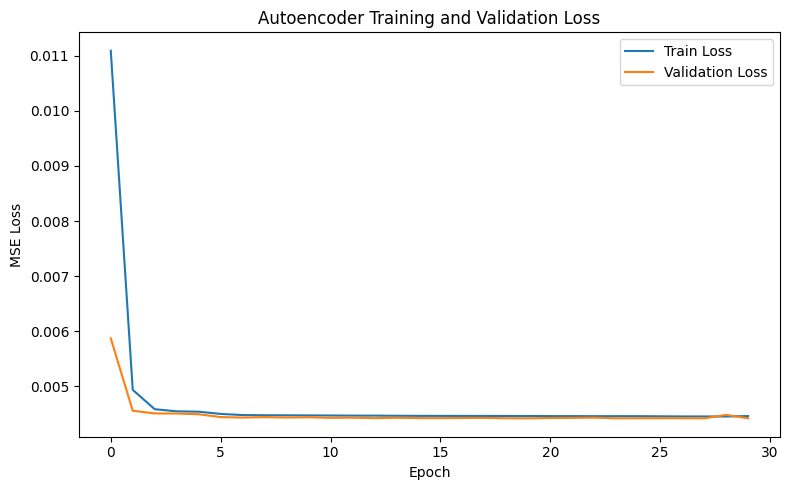

In [62]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Autoencoder Training and Validation Loss')
plt.legend()
plt.tight_layout()
plt.savefig("project/figures/autoencoder_loss_curve_pytorch.png", dpi=300)
plt.show()

In [63]:
model.eval()

with torch.no_grad():
    reconstructed = model(X_train_tensor)
    train_errors = torch.mean((X_train_tensor - reconstructed) ** 2, dim=1)

print(train_errors[:10])
print("Mean train reconstruction error:", train_errors.mean().item())

tensor([0.0045, 0.0043, 0.0044, 0.0045, 0.0044, 0.0045, 0.0045, 0.0045, 0.0045,
        0.0046])
Mean train reconstruction error: 0.00445286650210619


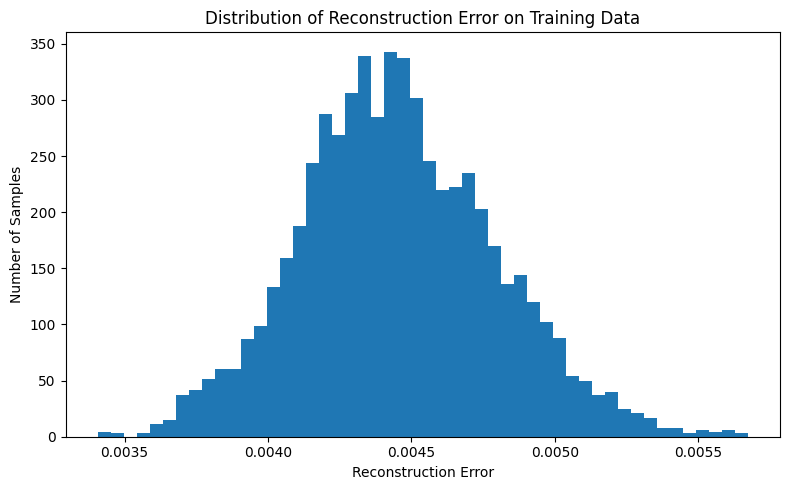

In [64]:
plt.figure(figsize=(8, 5))
plt.hist(train_errors.numpy(), bins=50)
plt.xlabel("Reconstruction Error")
plt.ylabel("Number of Samples")
plt.title("Distribution of Reconstruction Error on Training Data")
plt.tight_layout()
plt.show()